<a href="https://colab.research.google.com/github/Gowthami191/Brain-Tumour-Detection/blob/main/brain%20tumour.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os

path = '/content/drive/MyDrive/urop/urop/data'
os.listdir(path)


['Training', 'Testing']

In [ ]:
!pip install -q timm albumentations opencv-python-headless PyWavelets scikit-learn matplotlib seaborn
import torch
print("Torch Version:", torch.__version__)

Torch Version: 2.9.0+cu126


In [ ]:
import sys
import numpy as np
import torch
import cv2
import timm
import pywt

print("Python :", sys.version.split()[0])
print("NumPy  :", np.__version__)
print("Torch  :", torch.__version__, "| CUDA available:", torch.cuda.is_available())
print("OpenCV :", cv2.__version__)
print("timm   :", getattr(timm, "__version__", "timm loaded"))
print("pywt   :", pywt.__version__)

Python : 3.12.12
NumPy  : 2.0.2
Torch  : 2.9.0+cu126 | CUDA available: True
OpenCV : 4.12.0
timm   : 1.0.22
pywt   : 1.8.0


In [ ]:
import os, random, time, json, re
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

from torch.cuda.amp import GradScaler, autocast

# ------------------- seeds for reproducibility -------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True
# ----------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# SET your dataset root here (same as you used before)
DATASET_ROOT = "/content/drive/MyDrive/data"
assert os.path.exists(DATASET_ROOT), f"Dataset root not found: {DATASET_ROOT}"
print("DATASET_ROOT:", DATASET_ROOT)

Device: cuda
DATASET_ROOT: /content/drive/MyDrive/data


In [ ]:
ROOT = Path(DATASET_ROOT)
train_dir = None
test_dir = None

for root_path, dirs, files in os.walk(ROOT):
    for d in dirs:
        if d.lower() == "training":
            train_dir = Path(root_path) / d
        if d.lower() == "testing":
            test_dir = Path(root_path) / d
    if train_dir and test_dir:
        break

# fallback to any folder with 'train' / 'test' in name
if not train_dir:
    for root_path, dirs, files in os.walk(ROOT):
        for d in dirs:
            if "train" in d.lower():
                train_dir = Path(root_path) / d
                break
        if train_dir:
            break

if not test_dir:
    for root_path, dirs, files in os.walk(ROOT):
        for d in dirs:
            if "test" in d.lower():
                test_dir = Path(root_path) / d
                break
        if test_dir:
            break

print("Training dir:", train_dir)
print("Testing dir :", test_dir)

search_dir = train_dir if train_dir is not None else ROOT
classes = sorted([p.name for p in search_dir.iterdir() if p.is_dir()])
print("Detected classes:", classes)

Training dir: /content/drive/MyDrive/data/Training
Testing dir : /content/drive/MyDrive/data/Testing
Detected classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [ ]:
items = []

if train_dir and test_dir:
    for folder in [train_dir, test_dir]:
        for cls in classes:
            cls_path = folder / cls
            if cls_path.exists():
                for f in cls_path.rglob("*"):
                    if f.suffix.lower() in (".jpg", ".jpeg", ".png"):
                        items.append((str(f), cls))
else:
    for cls in classes:
        cls_path = (ROOT / cls) if (ROOT / cls).exists() else (search_dir / cls)
        if cls_path.exists():
            for f in cls_path.rglob("*"):
                if f.suffix.lower() in (".jpg", ".jpeg", ".png"):
                    items.append((str(f), cls))

print("Total images found:", len(items))
df = pd.DataFrame(items, columns=["path", "label"])
print(df["label"].value_counts())

# create stratified splits
if train_dir and test_dir:
    # use re.escape to handle special chars in path
    train_df = df[df["path"].str.contains(re.escape(str(train_dir)))].reset_index(drop=True)
    test_df  = df[df["path"].str.contains(re.escape(str(test_dir)))].reset_index(drop=True)

    if len(train_df) == 0:
        raise RuntimeError(f"No images found under training directory: {train_dir}")

    train_df, val_df = train_test_split(
        train_df,
        test_size=0.20,
        stratify=train_df["label"],
        random_state=SEED
    )
else:
    train_temp, test_df = train_test_split(
        df,
        test_size=0.10,
        stratify=df["label"],
        random_state=SEED
    )
    train_df, val_df = train_test_split(
        train_temp,
        test_size=0.1111,   # ~10% of original for val
        stratify=train_temp["label"],
        random_state=SEED
    )

print("Split sizes -> Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

os.makedirs("/content/outputs", exist_ok=True)
train_df.to_csv("/content/outputs/train_df.csv", index=False)
val_df.to_csv("/content/outputs/val_df.csv", index=False)
test_df.to_csv("/content/outputs/test_df.csv", index=False)

Total images found: 3264
label
meningioma_tumor    937
glioma_tumor        926
pituitary_tumor     901
no_tumor            500
Name: count, dtype: int64
Split sizes -> Train: 2296 Val: 574 Test: 394


In [ ]:
IMAGE_SIZE = 224

def normalize_mri(gray):
    # gray: uint8
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    norm = clahe.apply(gray)
    nf = norm.astype(np.float32)
    m = nf.mean()
    s = nf.std() if nf.std() > 1e-6 else 1.0
    z = (nf - m) / s
    scaled = 255.0 * ((z - z.min()) / (np.ptp(z) + 1e-8))
    return scaled.astype(np.uint8)

def wavelet(gray):
    arr = gray.astype(np.float32) / 255.0
    coeffs = pywt.wavedec2(arr, 'db2', level=1)
    cA = coeffs[0]
    if len(coeffs) > 1:
        cH, cV, cD = coeffs[1]
    else:
        cH = cV = cD = np.zeros_like(cA)

    det = np.abs(cH) + np.abs(cV) + np.abs(cD)
    H, W = gray.shape
    cA = cv2.resize(cA, (W, H))
    det = cv2.resize(det, (W, H))

    cA_u8 = (255 * (cA - cA.min()) / (np.ptp(cA) + 1e-8)).astype(np.uint8)
    det_u8 = (255 * (det - det.min()) / (np.ptp(det) + 1e-8)).astype(np.uint8)
    return cA_u8, det_u8

def sobel(gray):
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    mag = np.sqrt(gx * gx + gy * gy)
    return cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

In [ ]:
from albumentations import (
    Compose, Resize, Affine, GridDistortion, ElasticTransform,
    CoarseDropout, HorizontalFlip, Normalize
)

def get_transforms(phase='train'):
    mean = [0.5] * 4
    std  = [0.5] * 4

    if phase == 'train':
        return Compose([
            Resize(IMAGE_SIZE, IMAGE_SIZE),
            Affine(
                scale=(0.92, 1.08),
                translate_percent=(0.0, 0.06),
                rotate=(-15, 15),
                shear=None,
                fit_output=False,
                mode=cv2.BORDER_REFLECT,
                p=0.7
            ),
            GridDistortion(num_steps=5, distort_limit=0.03, p=0.3),
            ElasticTransform(alpha=1.0, sigma=50, alpha_affine=8, p=0.2),
            CoarseDropout(
                max_holes=2,
                max_height=int(IMAGE_SIZE * 0.12),
                max_width=int(IMAGE_SIZE * 0.12),
                p=0.3
            ),
            HorizontalFlip(p=0.5),
            Normalize(mean=mean, std=std),
            ToTensorV2()
        ], p=1.0)
    else:
        return Compose([
            Resize(IMAGE_SIZE, IMAGE_SIZE),
            Normalize(mean=mean, std=std),
            ToTensorV2()
        ], p=1.0)


In [ ]:
# ===== DATASET + SAMPLER + DATALOADERS =====

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# Redefine get_transforms here to fix the issue
from albumentations import (
    Compose, Resize, Affine, GridDistortion, ElasticTransform,
    CoarseDropout, HorizontalFlip, Normalize
)

IMAGE_SIZE = 224 # IMAGE_SIZE is used here, so it needs to be defined or imported

def get_transforms(phase='train'):
    mean = [0.5] * 4
    std  = [0.5] * 4

    if phase == 'train':
        return Compose([
            Resize(IMAGE_SIZE, IMAGE_SIZE),
            Affine(
                scale=(0.92, 1.08),
                translate_percent=(0.0, 0.06),
                rotate=(-15, 15),
                # shear=None,  # Removed this line in previous turn
                fit_output=False,
                # mode=cv2.BORDER_REFLECT,  # Removed invalid 'mode' argument
                p=0.7
            ),
            GridDistortion(num_steps=5, distort_limit=0.03, p=0.3),
            ElasticTransform(alpha=1.0, sigma=50, # Removed invalid 'alpha_affine' argument
                             p=0.2),
            CoarseDropout(
                # Removed invalid 'max_holes', 'max_height', 'max_width' arguments
                p=0.3
            ),
            HorizontalFlip(p=0.5),
            Normalize(mean=mean, std=std),
            ToTensorV2()
        ], p=1.0)
    else:
        return Compose([
            Resize(IMAGE_SIZE, IMAGE_SIZE),
            Normalize(mean=mean, std=std),
            ToTensorV2()
        ], p=1.0)


class WaveletDataset(Dataset):
    def __init__(self, df, classes, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.classes = classes

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]
        path = row["path"]
        label_idx = self.classes.index(row["label"])

        gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if gray is None:
            raise RuntimeError("Cannot read image: " + path)

        gray = normalize_mri(gray)
        cA, det = wavelet(gray)
        sb = sobel(gray)

        stacked = np.stack([gray, cA, det, sb], axis=-1).astype(np.uint8)
        aug = self.transform(image=stacked)
        return aug["image"], label_idx


# create datasets
train_ds = WaveletDataset(train_df, classes, get_transforms('train'))
val_ds   = WaveletDataset(val_df, classes, get_transforms('val'))
test_ds  = WaveletDataset(test_df, classes, get_transforms('val'))

# ----- Weighted sampler for class imbalance -----
train_labels_list = train_df["label"].tolist()
label_to_idx = {c: i for i, c in enumerate(classes)}
train_label_indices = [label_to_idx[l] for l in train_labels_list]

class_counts = np.array([train_label_indices.count(i) for i in range(len(classes))])
class_weights = 1.0 / (class_counts + 1e-8)
sample_weights = [class_weights[idx] for idx in train_label_indices]

sampler = WeightedRandomSampler(
    torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

# ----- Dataloaders (with safe pin_memory) -----
BATCH_SIZE = 8   # you can change this if GPU allows more
use_pin_memory = (device.type == "cuda")

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=1,
    pin_memory=use_pin_memory
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=1,
    pin_memory=use_pin_memory
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=1,
    pin_memory=use_pin_memory
)

print("DataLoaders prepared. Train/Val/Test sizes:",
      len(train_ds), len(val_ds), len(test_ds))
print("Device:", device, "| pin_memory:", use_pin_memory)


DataLoaders prepared. Train/Val/Test sizes: 2296 574 394
Device: cuda | pin_memory: True


In [ ]:
class SwinHybridModel(nn.Module):
    def __init__(
        self,
        backbone_name='swin_base_patch4_window7_224',  # widely available in timm
        in_chans=4,
        num_classes=len(classes),
        dropout=0.35
    ):
        super().__init__()

        self.backbone = timm.create_model(
            backbone_name,
            pretrained=True,
            in_chans=in_chans,
            num_classes=0  # feature extractor (global pooled features)
        )
        feat_dim = self.backbone.num_features

        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Dropout(dropout),
            nn.Linear(feat_dim, num_classes)
        )

    def forward(self, x):
        feats = self.backbone(x)   # (B, feat_dim)
        logits = self.head(feats)  # (B, num_classes)
        return logits

model = SwinHybridModel().to(device)
print("Swin model params:", sum(p.numel() for p in model.parameters()))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Swin model params: 86751420


In [ ]:
from torch.amp import GradScaler, autocast # Changed import from torch.cuda.amp to torch.amp

scaler = GradScaler()

criterion = nn.CrossEntropyLoss(label_smoothing=0.1).to(device)

# slightly lower LR for a big transformer backbone
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=8
)

def mixup_data(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(device)
    mixed_x = lam * x + (1.0 - lam) * x[idx]
    return mixed_x, y, y[idx], lam

def cutmix_data(x, y, alpha=1.0):
    if alpha <= 0:
        return x, y, y, 1.0

    lam = np.random.beta(alpha, alpha)
    b, c, h, w = x.size()
    idx = torch.randperm(b).to(device)

    cx = np.random.randint(w)
    cy = np.random.randint(h)

    cut_w = int(w * np.sqrt(1 - lam))
    cut_h = int(h * np.sqrt(1 - lam))

    x1 = np.clip(cx - cut_w // 2, 0, w)
    x2 = np.clip(cx + cut_w // 2, 0, w)
    y1 = np.clip(cy - cut_h // 2, 0, h)
    y2 = np.clip(cy + cut_h // 2, 0, h)

    x[:, :, y1:y2, x1:x2] = x[idx, :, y1:y2, x1:x2]
    lam_adj = 1.0 - ((x2 - x1) * (y2 - y1) / (w * h))

    return x, y, y[idx], lam_adj

def run_eval(model, loader):
    model.eval()
    preds_all = []
    labels_all = []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            with autocast(device_type='cuda', enabled=(device.type == 'cuda')):
                logits = model(imgs)
            preds_all.extend(logits.argmax(1).cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
    f1 = f1_score(labels_all, preds_all, average='macro')
    acc = accuracy_score(labels_all, preds_all)
    return f1, acc, np.array(labels_all), np.array(preds_all)


In [ ]:
import time # Added this import

EPOCHS = 25
best_val = 0.0
patience = 6
pat_count = 0
start_time = time.time()

best_model_path = "/content/best_swin_model.pth"

for epoch in range(EPOCHS):
    model.train()
    preds_train = []
    labels_train = []

    mixup_alpha = 0.2 if epoch < 6 else 0.0
    cutmix_p = 0.12 if epoch < 6 else 0.25

    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        r = random.random()

        if r < cutmix_p:
            x_mix, ya, yb, lam = cutmix_data(imgs.clone(), labels, alpha=1.0)
            with autocast(device_type='cuda', enabled=(device.type == 'cuda')):
                logits = model(x_mix)
                loss = lam * criterion(logits, ya) + (1.0 - lam) * criterion(logits, yb)
        elif mixup_alpha > 0 and r < (cutmix_p + 0.35):
            x_mix, ya, yb, lam = mixup_data(imgs, labels, alpha=mixup_alpha)
            with autocast(device_type='cuda', enabled=(device.type == 'cuda')):
                logits = model(x_mix)
                loss = lam * criterion(logits, ya) + (1.0 - lam) * criterion(logits, yb)
        else:
            with autocast(device_type='cuda', enabled=(device.type == 'cuda')):
                logits = model(imgs)
                loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds_train.extend(logits.argmax(1).cpu().numpy())
        labels_train.extend(labels.cpu().numpy())

    train_f1 = f1_score(labels_train, preds_train, average='macro')

    # validation
    val_f1, val_acc, _, _ = run_eval(model, val_loader)
    scheduler.step()

    elapsed = (time.time() - start_time) / 60.0
    print(f"Epoch {epoch+1}/{EPOCHS} — "
          f"Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f} | Val Acc: {val_acc*100:.2f}% | "
          f"elapsed(min): {elapsed:.1f}")

    if val_f1 > best_val + 1e-4:
        best_val = val_f1
        torch.save(
            {"model_state": model.state_dict(), "classes": classes},
            best_model_path
        )
        pat_count = 0
        print("Saved best model (Val F1:", best_val, ")")
    else:
        pat_count += 1
        if pat_count >= patience:
            print("Early stopping — no improvement")
            break

print("Training finished. Best val F1:", best_val)

Epoch 1/25 — Train F1: 0.6301 | Val F1: 0.8686 | Val Acc: 86.59% | elapsed(min): 17.2
Saved best model (Val F1: 0.8686016254357136 )
Epoch 2/25 — Train F1: 0.7618 | Val F1: 0.9393 | Val Acc: 93.55% | elapsed(min): 23.4
Saved best model (Val F1: 0.939311901603707 )
Epoch 3/25 — Train F1: 0.8077 | Val F1: 0.9519 | Val Acc: 95.12% | elapsed(min): 26.7
Saved best model (Val F1: 0.9518792246752095 )
Epoch 4/25 — Train F1: 0.8265 | Val F1: 0.9438 | Val Acc: 94.08% | elapsed(min): 29.1
Epoch 5/25 — Train F1: 0.8218 | Val F1: 0.9582 | Val Acc: 95.47% | elapsed(min): 31.0
Saved best model (Val F1: 0.9582353880707151 )
Epoch 6/25 — Train F1: 0.8585 | Val F1: 0.9607 | Val Acc: 95.82% | elapsed(min): 32.6
Saved best model (Val F1: 0.9606763754656196 )
Epoch 7/25 — Train F1: 0.9278 | Val F1: 0.9732 | Val Acc: 97.21% | elapsed(min): 34.2
Saved best model (Val F1: 0.9732434062469473 )
Epoch 8/25 — Train F1: 0.9375 | Val F1: 0.9643 | Val Acc: 96.17% | elapsed(min): 35.8
Epoch 9/25 — Train F1: 0.9181 |

In [ ]:
import time # Added this import

EPOCHS = 25
best_val = 0.0
patience = 6
pat_count = 0
start_time = time.time()

best_model_path = "/content/best_swin_model.pth"

for epoch in range(EPOCHS):
    model.train()
    preds_train = []
    labels_train = []

    mixup_alpha = 0.2 if epoch < 6 else 0.0
    cutmix_p = 0.12 if epoch < 6 else 0.25

    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        r = random.random()

        if r < cutmix_p:
            x_mix, ya, yb, lam = cutmix_data(imgs.clone(), labels, alpha=1.0)
            with autocast(device_type='cuda', enabled=(device.type == 'cuda')):
                logits = model(x_mix)
                loss = lam * criterion(logits, ya) + (1.0 - lam) * criterion(logits, yb)
        elif mixup_alpha > 0 and r < (cutmix_p + 0.35):
            x_mix, ya, yb, lam = mixup_data(imgs, labels, alpha=mixup_alpha)
            with autocast(device_type='cuda', enabled=(device.type == 'cuda')):
                logits = model(x_mix)
                loss = lam * criterion(logits, ya) + (1.0 - lam) * criterion(logits, yb)
        else:
            with autocast(device_type='cuda', enabled=(device.type == 'cuda')):
                logits = model(imgs)
                loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds_train.extend(logits.argmax(1).cpu().numpy())
        labels_train.extend(labels.cpu().numpy())

    train_f1 = f1_score(labels_train, preds_train, average='macro')

    # validation
    val_f1, val_acc, _, _ = run_eval(model, val_loader)
    scheduler.step()

    elapsed = (time.time() - start_time) / 60.0
    print(f"Epoch {epoch+1}/{EPOCHS} — "
          f"Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f} | Val Acc: {val_acc*100:.2f}% | "
          f"elapsed(min): {elapsed:.1f}")

    if val_f1 > best_val + 1e-4:
        best_val = val_f1
        torch.save(
            {"model_state": model.state_dict(), "classes": classes},
            best_model_path
        )
        pat_count = 0
        print("Saved best model (Val F1:", best_val, ")")
    else:
        pat_count += 1
        if pat_count >= patience:
            print("Early stopping — no improvement")
            break

print("Training finished. Best val F1:", best_val)

Epoch 1/25 — Train F1: 0.8395 | Val F1: 0.9520 | Val Acc: 94.77% | elapsed(min): 1.6
Saved best model (Val F1: 0.9519683703357591 )
Epoch 2/25 — Train F1: 0.8514 | Val F1: 0.9720 | Val Acc: 97.04% | elapsed(min): 3.2
Saved best model (Val F1: 0.9720060208138618 )
Epoch 3/25 — Train F1: 0.8650 | Val F1: 0.9794 | Val Acc: 97.91% | elapsed(min): 4.7
Saved best model (Val F1: 0.9794036499838821 )
Epoch 4/25 — Train F1: 0.8692 | Val F1: 0.9766 | Val Acc: 97.39% | elapsed(min): 6.2
Epoch 5/25 — Train F1: 0.8668 | Val F1: 0.9811 | Val Acc: 97.91% | elapsed(min): 7.7
Saved best model (Val F1: 0.9811318543012887 )
Epoch 6/25 — Train F1: 0.8781 | Val F1: 0.9766 | Val Acc: 97.39% | elapsed(min): 9.3
Epoch 7/25 — Train F1: 0.9594 | Val F1: 0.9782 | Val Acc: 97.56% | elapsed(min): 10.8
Epoch 8/25 — Train F1: 0.9376 | Val F1: 0.9758 | Val Acc: 97.39% | elapsed(min): 12.3
Epoch 9/25 — Train F1: 0.9485 | Val F1: 0.9699 | Val Acc: 97.04% | elapsed(min): 13.7
Epoch 10/25 — Train F1: 0.9473 | Val F1: 0.9

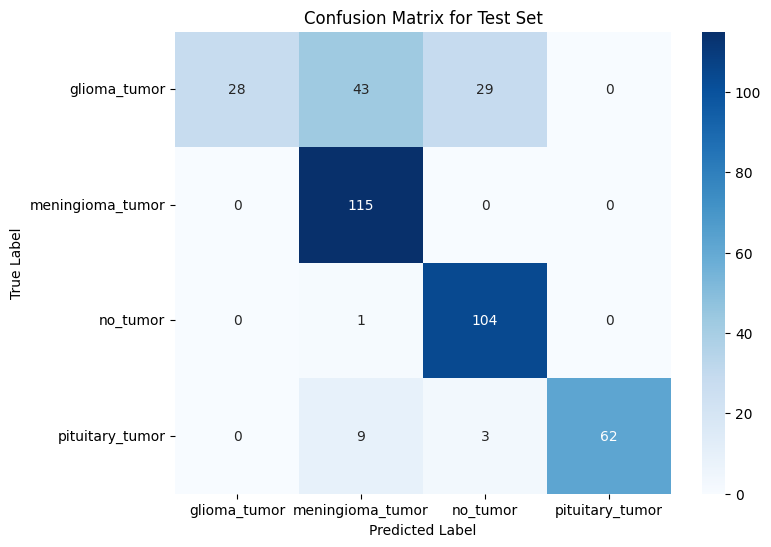

In [ ]:
import torch
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Load the best model
best_model_data = torch.load(best_model_path)
model.load_state_dict(best_model_data["model_state"])
model.eval()

# Run evaluation on the test set
_, _, true_labels, predictions = run_eval(model, test_loader)

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Test Set')
plt.show()